In [17]:
import SpaceBalls.input_database_manager as input_db_manager
from SpaceBalls.postproc_EEI_estimation import get_simulated_accelerometer_measurements, get_output_variable_hist
from SpaceBalls.plotter import Plotter
from SpaceBalls.sph_meshing import fibonacci_sphere, get_faceted_sphere_mesh
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
from scipy.stats import uniform_direction
%matplotlib inline

def get_random_vectors(n):
    return uniform_direction.rvs(dim=3, size=n)


def get_avg_cross_sectional_area(normal_vecs, areas, all_s, cs, cd, ca, solar_panels_frac=0):

    all_areas = []
    all_vecs = []

    cs_solar = 0.05
    cd_solar = 0.3
    ca_solar = 0.65

    if solar_panels_frac>0:
        solar_panel_cell_idxs = np.random.choice(len(areas),(int(solar_panels_frac*len(areas)),), replace=False)
        area_frac_solar_panels = np.sum(areas[solar_panel_cell_idxs]) / np.sum(areas)
        area_frac_rest = 1 - area_frac_solar_panels

        ca_eff = ca_solar * area_frac_solar_panels + ca * area_frac_rest
        cd_eff = cd_solar * area_frac_solar_panels + cd * area_frac_rest
        cs_eff = cs_solar * area_frac_solar_panels + cs * area_frac_rest
        eff_coeffs = (ca_eff, cd_eff, cs_eff)

    else:
        solar_panel_cell_idxs = []
        eff_coeffs = None

    for i, s in enumerate(all_s):
        total_vec = np.zeros(3)
        total_A = 0

        for i, (n, area) in enumerate(zip(normal_vecs, areas)):

            if i in solar_panel_cell_idxs:
                ca_i, cd_i, cs_i = ca_solar, cd_solar, cs_solar
            else:
                ca_i, cd_i, cs_i = ca, cd, cs

            cos = np.max([0, np.dot(-s, n)])
            vec = area * cos * ((ca_i+cd_i) * s - (2/3*cd_i + 2*cos*cs_i) * n)
            total_vec += vec
            total_A += area * cos
        #print(f"cos gamma: {cos}")

        all_areas.append(total_A)
        all_vecs.append(total_vec)
    
    return np.asarray(all_areas), np.asarray(all_vecs), eff_coeffs

n_vertices: 252
Number of faces: 500


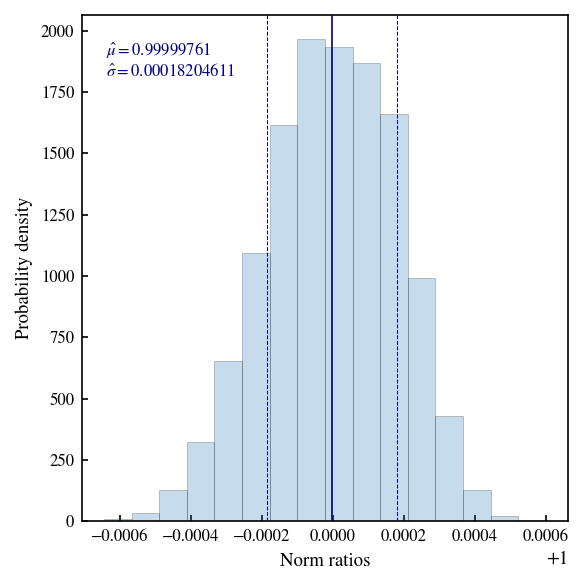

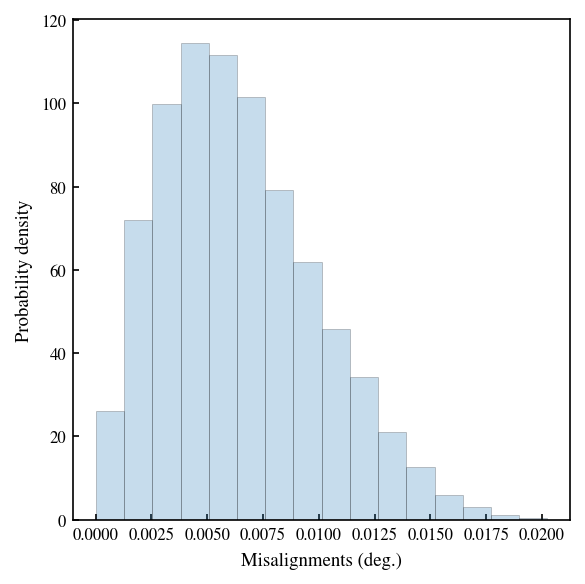

In [23]:
radius_meters = 1
A_sphere = np.pi * radius_meters**2
n_facets = 500 #72 # 500
cs=0.68
cd=0.2
ca=0.12

all_s = -get_random_vectors(20000) #fibonacci_sphere(1, n=4500)
mesh = get_faceted_sphere_mesh(radius_meters, n_facets, default_golden=False)
vertices, centroids, normal_vecs, areas, edge_conns, hull = mesh

solar_panels_frac = 0
all_areas, all_vecs, eff_coeffs = get_avg_cross_sectional_area(normal_vecs, areas, all_s, 
                                                   cs=cs, cd=cd, ca=ca, solar_panels_frac=solar_panels_frac)

actual_avg_area = np.mean(all_areas)
if solar_panels_frac>0:
    cd_eff = eff_coeffs[1]
else:
    cd_eff = cd

norm_ratios = np.zeros(len(all_s))
misalignments = np.zeros(len(all_s))

for i, (s, A, F) in enumerate(zip(all_s, all_areas, all_vecs)):
    #F_cannonball = s * A_sphere * (1 + cs + cd*5/3)
    F_cannonball = s * actual_avg_area * (1 + cd_eff*4/9)
    

    F_plated_norm = np.linalg.norm(F)
    F_cannonball_norm = np.linalg.norm(F_cannonball)
    misalignments[i] = np.degrees(np.acos(np.dot(F,F_cannonball) / (F_plated_norm * F_cannonball_norm)))
    norm_ratios[i] = F_cannonball_norm / F_plated_norm

    #print(f"norm_ratio: {norm_ratio:.5f};  misalignment: {misalign:.5f} deg")

Plotter.plot_histogram(norm_ratios, xlabel='Norm ratios', 
                       add_mean=True,
                        add_std=True,
                        stats_format=".8g",
                        stats_color="navy",        # or "black"
                        label_placement="corner",   # or "corner"
)

Plotter.plot_histogram(misalignments, xlabel='Misalignments (deg.)', 
                       add_mean=False,
                        add_std=False
)

In [ ]:
n_facets_vec = [24, 48, 72, 96, 120, 180, 280, 450] #, 450]
radius_meters = 1    

for i, n_facets in enumerate(n_facets_vec):
    print(f"n_facets = {n_facets}")
    mesh = get_faceted_sphere_mesh(radius_meters, n_facets, default_golden=False)
    vertices, centroids, normal_vecs, areas, edge_conns, hull = mesh
    actual_area = get_avg_cross_sectional_area(normal_vecs, areas)